# Q-Learning Grid World Assignment Part 1

The solution is divided into 4 sections, respectivily

**Section 0:** Setup and display the initial grid

**Section 1:** Plot the converged policy and value function for this grid world

**Section 2:** Do it for γ = 0.1, 0.5, and 0.9 with constant β = 0.1

**Section 3:** For γ = 0.9, plot the number of steps to reach the goal across episodes for β = 0.1, 0.3, and 0.5


## Setup and Display Initial Environment


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from collections import deque
import time
import os

In [5]:
NUM_EPISODES = 20000

GRID_SIZE = 5
START_STATE_GRID1 = [1, 1]
OBSTACLES_GRID1 = [[2, 4], [3, 4], [3, 2]]
GOAL_STATE_GRID2 = [5, 5]
TERMINAL_STATE_GRID2 = [4, 1]
OBSTACLES_GRID2 = [[2, 2], [2, 3], [2, 4], [3, 4], [4, 3]]
WINDOW_GRID1 = [3, 5]
WINDOW_GRID2 = [3, 1]
GOAL_REWARD = 5
TERMINAL_REWARD = -5
BOUNDARY_REWARD = -1

MAX_STEPS = (GRID_SIZE * GRID_SIZE * 2) * 10
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.9
BETA = 1.0  # Inverse temperature parameter for softmax policy
np.random.seed(88)
NUM_ACTIONS = 4
NUM_STATES = (GRID_SIZE * GRID_SIZE * 2) + 1

SAVE_AND_SHOW = True # Set to True to save and show else only show

In [6]:
def save_or_show(fig, name, gamma=DISCOUNT_FACTOR, beta=BETA):
    out_dir = "question2_fig"
    os.makedirs(out_dir, exist_ok=True)
    filename = f"{out_dir}/{name}_gamma_{gamma}_beta_{beta}.png"
    if SAVE_AND_SHOW:
        fig.savefig(filename, bbox_inches='tight', dpi=150)
        print(f"Saved figure: {filename}")
    plt.show()        

In [7]:
def print_environment_setup():
    print("DUAL-GRID ENVIRONMENT SETUP\n")
    print(f"Grid Size: {GRID_SIZE}x{GRID_SIZE} each")
    print(f"Total States: {NUM_STATES}")
    print(f"Start: Grid 1 {START_STATE_GRID1}")
    print(f"Goal: Grid 2 {GOAL_STATE_GRID2} with Reward {GOAL_REWARD}")
    print(f"Terminal: Grid 2 {TERMINAL_STATE_GRID2} with Reward {TERMINAL_REWARD}")
    print(f"Obstacles in Grid 1: {OBSTACLES_GRID1}")
    print(f"Obstacles in Grid 2: {OBSTACLES_GRID2}")
    print(f"Learning Rate: {LEARNING_RATE}, Discount Factor: {DISCOUNT_FACTOR}, BETA: {BETA}")
    print(f"Number of Episodes: {NUM_EPISODES}, Max Steps per Episode: {MAX_STEPS}")

In [8]:
def plot_environment():
    fig, ax = plt.subplots(figsize=(13, 6))
    offset_x = GRID_SIZE + 1
    window_y = WINDOW_GRID1[0] - 1
    window_x_start = GRID_SIZE

    def draw_grid(x_offset=0, color='black'):
        for i in range(GRID_SIZE + 1):
            ax.plot([x_offset, x_offset + GRID_SIZE], [i, i], color=color, linewidth=1)
            ax.plot([x_offset + i, x_offset + i], [0, GRID_SIZE], color=color, linewidth=1)

    def draw_border(x_offset=0):
        x = [x_offset, x_offset, x_offset + GRID_SIZE, x_offset + GRID_SIZE, x_offset]
        y = [0, GRID_SIZE, GRID_SIZE, 0, 0]
        ax.plot(x, y, color='red', linewidth=2.5)

    def draw_state(state, label, color, edge, offset=0):
        x, y = state[1] - 0.5 + offset, state[0] - 0.5
        ax.plot(x, y, 's', markerfacecolor=color, markersize=30,
                markeredgecolor=edge, markeredgewidth=2)
        ax.text(x, y, label, color='white', fontsize=16, fontweight='bold', ha='center', va='center')

    def draw_obstacles(obstacles, offset=0):
        for r, c in obstacles:
            ax.add_patch(plt.Rectangle((c - 1 + offset, r - 1), 1, 1, color='black'))

    # --- Draw both grids ---
    draw_grid()
    draw_grid(offset_x)

    # --- Window ---
    for i in range(2):
        ax.plot([window_x_start, window_x_start + 1], [window_y + i, window_y + i], color='black', linewidth=1)
        ax.plot([window_x_start + i, window_x_start + i], [window_y, window_y + 1], color='black', linewidth=1)

    # --- Borders ---
    draw_border()
    draw_border(offset_x)
    ax.plot([window_x_start, window_x_start + 1], [window_y, window_y], color='red', linewidth=2.5)
    ax.plot([window_x_start, window_x_start + 1], [window_y + 1, window_y + 1], color='red', linewidth=2.5)
    ax.plot([window_x_start, window_x_start], [window_y, window_y + 1], color='black', linewidth=5)
    ax.plot([window_x_start + 1, window_x_start + 1], [window_y, window_y + 1], color='black', linewidth=5)

    # --- States & Obstacles ---
    draw_state(START_STATE_GRID1, 'A', '#4B72B0', 'navy')
    draw_state(GOAL_STATE_GRID2, 'G', '#2CA02C', 'darkgreen', offset_x)
    draw_state(TERMINAL_STATE_GRID2, 'T', '#D62728', 'darkred', offset_x)
    draw_obstacles(OBSTACLES_GRID1)
    draw_obstacles(OBSTACLES_GRID2, offset_x)

    # --- Formatting ---
    ax.set(xlim=[-1, offset_x + GRID_SIZE + 1], ylim=[GRID_SIZE + 1, -1],
           xticks=[], yticks=[], aspect='equal', title='Initial Environment')
    plt.tight_layout()
    save_or_show(fig, "initial_environment")


DUAL-GRID ENVIRONMENT SETUP

Grid Size: 5x5 each
Total States: 51
Start: Grid 1 [1, 1]
Goal: Grid 2 [5, 5] with Reward 5
Terminal: Grid 2 [4, 1] with Reward -5
Obstacles in Grid 1: [[2, 4], [3, 4], [3, 2]]
Obstacles in Grid 2: [[2, 2], [2, 3], [2, 4], [3, 4], [4, 3]]
Learning Rate: 0.1, Discount Factor: 0.9, BETA: 1.0
Number of Episodes: 20000, Max Steps per Episode: 500
Saved figure: question2_fig/initial_environment_gamma_0.9_beta_1.0.png


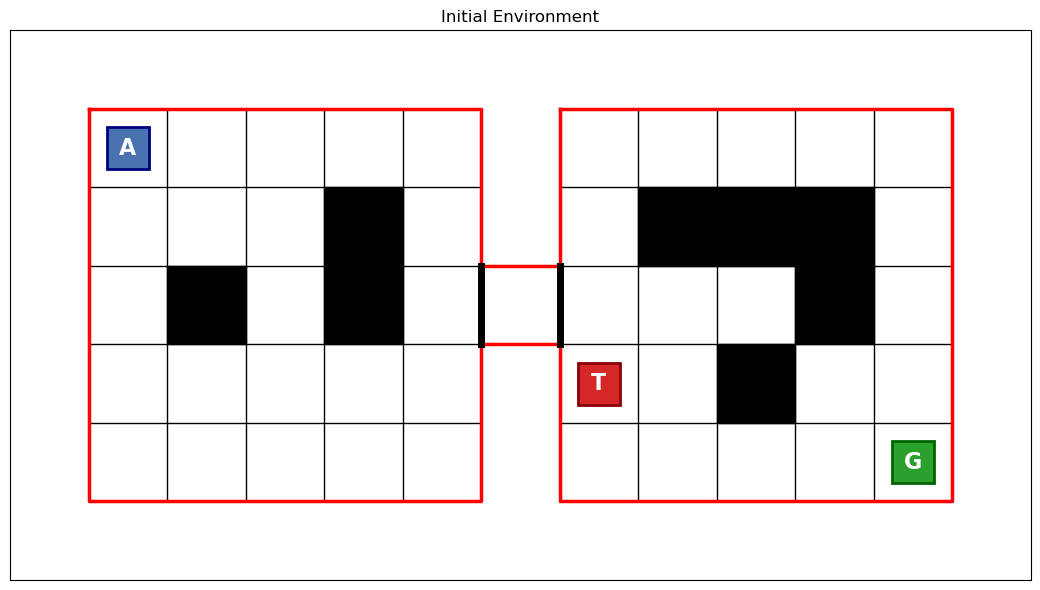

In [9]:
print_environment_setup()
plot_environment()

## Helper Functions

In [10]:
WINDOW_STATE_INDEX = GRID_SIZE * GRID_SIZE * 2
def encode_state(grid, row, col):
    if grid == 1:
        return (row - 1) * GRID_SIZE + (col - 1)
    elif grid == 2:
        return GRID_SIZE * GRID_SIZE + ((row - 1) * GRID_SIZE + (col - 1))
    else:
        raise ValueError("grid must be 1 or 2; window uses WINDOW_STATE_INDEX directly")
def decode_state(index):
    if index == WINDOW_STATE_INDEX:
        return 'W', WINDOW_GRID1[0], WINDOW_GRID1[1]
    if 0 <= index < GRID_SIZE * GRID_SIZE:
        row = index // GRID_SIZE + 1
        col = index % GRID_SIZE + 1
        return 1, row, col
    base2 = GRID_SIZE * GRID_SIZE
    if base2 <= index < base2 + GRID_SIZE * GRID_SIZE:
        local = index - base2
        row = local // GRID_SIZE + 1
        col = local % GRID_SIZE + 1
        return 2, row, col
    raise ValueError(f"Invalid state index {index}")
def is_valid_cell(grid, row, col):
    if grid == 'W':
        return True
    if not (1 <= row <= GRID_SIZE and 1 <= col <= GRID_SIZE):
        return False
    if grid == 1 and [row, col] in OBSTACLES_GRID1:
        return False
    if grid == 2 and [row, col] in OBSTACLES_GRID2:
        return False
    return True
def is_terminal_cell(grid, row, col):
    if grid != 2:
        return False
    return ([row, col] == GOAL_STATE_GRID2) or ([row, col] == TERMINAL_STATE_GRID2)
def get_state(coordinates, size):
    return (coordinates[0] - 1) * size + coordinates[1]
def get_coordinates(state, size):
    return [(state - 1) // size + 1, (state - 1) % size + 1]
def is_valid_state(state, size, obstacles):
    return (1 <= state[0] <= size) and (1 <= state[1] <= size) and (state not in obstacles)
def is_terminal_state(state, goal, terminal):
    return state == goal or state == terminal

In [11]:
def step(current_state, action, size, goal, terminal, obstacles):
    if is_terminal_state(current_state, goal, terminal):
        return current_state, 0, True

    if action == 'N':
        next_state = [current_state[0] - 1, current_state[1]]
    elif action == 'S':
        next_state = [current_state[0] + 1, current_state[1]]
    elif action == 'E':
        next_state = [current_state[0], current_state[1] + 1]
    elif action == 'W':
        next_state = [current_state[0], current_state[1] - 1]
    else:
        raise ValueError("Invalid action")

    if is_valid_state(next_state, size, obstacles):
        if next_state == goal:
            return next_state, GOAL_REWARD, True
        elif next_state == terminal:
            return next_state, TERMINAL_REWARD, True
        else:
            return next_state, 0, False
    else:
        if (next_state[0] < 1) or (next_state[1] < 1) or (next_state[0] > size) or (next_state[1] > size):
            return current_state, BOUNDARY_REWARD, False
        else:
            return current_state, 0, False

In [12]:
def draw_environment(ax, offset_x, window_x_start, window_y):
    def draw_grid(x_offset=0, color='black'):
        for i in range(GRID_SIZE + 1):
            ax.plot([x_offset, x_offset + GRID_SIZE], [i, i], color=color, linewidth=1)
            ax.plot([x_offset + i, x_offset + i], [0, GRID_SIZE], color=color, linewidth=1)

    def draw_border(x_offset=0):
        x = [x_offset, x_offset, x_offset + GRID_SIZE, x_offset + GRID_SIZE, x_offset]
        y = [0, GRID_SIZE, GRID_SIZE, 0, 0]
        ax.plot(x, y, color='red', linewidth=2.5)

    def draw_obstacles(obstacles, offset=0):
        for r, c in obstacles:
            ax.add_patch(plt.Rectangle((c - 1 + offset, r - 1), 1, 1, color='black'))

    # --- Grids and Borders ---
    draw_grid(0)
    draw_grid(offset_x)
    draw_border(0)
    draw_border(offset_x)

    # --- Window between grids (replicating plot_environment style) ---
    # Horizontal top/bottom lines
    ax.plot([window_x_start, window_x_start + 1], [window_y, window_y], color='red', linewidth=2.5)
    ax.plot([window_x_start, window_x_start + 1], [window_y + 1, window_y + 1], color='red', linewidth=2.5)
    # Vertical thick sides
    ax.plot([window_x_start, window_x_start], [window_y, window_y + 1], color='black', linewidth=5)
    ax.plot([window_x_start + 1, window_x_start + 1], [window_y, window_y + 1], color='black', linewidth=5)

    # --- Obstacles ---
    draw_obstacles(OBSTACLES_GRID1)
    draw_obstacles(OBSTACLES_GRID2, offset_x)


### Q-Learning Algorithm

In [13]:
def softmax_action_selection(Q_values, beta):
    temperature = 1.0 / beta if beta > 0 else 1.0
    exp_values = np.exp((Q_values - np.max(Q_values)) / temperature)
    probs = exp_values / np.sum(exp_values)
    return np.random.choice(len(Q_values), p=probs)

def transition(grid, row, col, action):
    if grid == 2 and [row, col] in [GOAL_STATE_GRID2, TERMINAL_STATE_GRID2]:
        reward = GOAL_REWARD if [row, col] == GOAL_STATE_GRID2 else TERMINAL_REWARD
        return grid, row, col, reward, True

    if grid == 1 and [row, col] == WINDOW_GRID1 and action == 'E':
        return 'W', row, col, 0, False
    if grid == 2 and [row, col] == WINDOW_GRID2 and action == 'W':
        return 'W', row, col, 0, False

    if grid == 'W':
        if action == 'W': return 1, WINDOW_GRID1[0], WINDOW_GRID1[1], 0, False
        if action == 'E': return 2, WINDOW_GRID2[0], WINDOW_GRID2[1], 0, False
        return 'W', row, col, BOUNDARY_REWARD, False

    dr, dc = {'N': (-1, 0), 'S': (1, 0), 'W': (0, -1), 'E': (0, 1)}[action]
    new_row, new_col = row + dr, col + dc

    if not (1 <= new_row <= GRID_SIZE and 1 <= new_col <= GRID_SIZE):
        return grid, row, col, BOUNDARY_REWARD, False
    if [new_row, new_col] in (OBSTACLES_GRID1 if grid == 1 else OBSTACLES_GRID2):
        return grid, row, col, 0, False

    if grid == 2 and [new_row, new_col] == GOAL_STATE_GRID2:
        return grid, new_row, new_col, GOAL_REWARD, True
    if grid == 2 and [new_row, new_col] == TERMINAL_STATE_GRID2:
        return grid, new_row, new_col, TERMINAL_REWARD, True

    return grid, new_row, new_col, 0, False


In [14]:

def run_q_learning(gamma, beta, num_eps=NUM_EPISODES):
    Q = 0.001 * np.random.rand(NUM_STATES, NUM_ACTIONS)
    episode_rewards, steps_per_episode = [], []
    actions = ['N', 'S', 'W', 'E']
    if num_eps >= 1000:
        progress_interval = min(10000, max(1, num_eps // 10))
    else:
        progress_interval = None

    for ep in range(num_eps):
        grid, row, col = 1, *START_STATE_GRID1
        total_reward, steps = 0, 0

        for _ in range(MAX_STEPS):
            state_idx = encode_state(grid, row, col) if grid in (1, 2) else WINDOW_STATE_INDEX
            a_idx = softmax_action_selection(Q[state_idx], beta)
            new_grid, new_row, new_col, reward, done = transition(grid, row, col, actions[a_idx])
            next_idx = WINDOW_STATE_INDEX if new_grid == 'W' else encode_state(new_grid, new_row, new_col)

            td_target = reward + gamma * (0 if done else np.max(Q[next_idx]))
            Q[state_idx, a_idx] += LEARNING_RATE * (td_target - Q[state_idx, a_idx])

            total_reward += reward
            grid, row, col = new_grid, new_row, new_col
            steps += 1
            if done:
                break

        episode_rewards.append(total_reward)
        steps_per_episode.append(steps)

        if progress_interval and (ep + 1) % progress_interval == 0:
         avg_recent_steps = np.mean(steps_per_episode[-progress_interval:]) if len(steps_per_episode) >= progress_interval else np.mean(steps_per_episode)
         avg_recent_rewards = np.mean(episode_rewards[-progress_interval:]) if len(episode_rewards) >= progress_interval else np.mean(episode_rewards)
         print(f"    Episode {ep + 1}/{num_eps} - Avg steps (last {min(ep + 1, progress_interval)}): {avg_recent_steps:.2f}, Avg reward: {avg_recent_rewards:.2f}")

    return Q, episode_rewards, steps_per_episode


## Section 1: Plot the Converged Policy and Value Function


In [15]:
def plot_policy(Q_table, gamma, beta):
    action_symbols = ['↑', '↓', '←', '→']
    offset_x, window_x_start, window_y = GRID_SIZE + 1, GRID_SIZE, WINDOW_GRID1[0] - 1
    fig, ax = plt.subplots(figsize=(14, 6))
    draw_environment(ax, offset_x, window_x_start, window_y)
    for grid, x_off in [(1, 0), (2, offset_x)]:
        for r in range(1, GRID_SIZE + 1):
            for c in range(1, GRID_SIZE + 1):
                if grid == 1 and [r, c] in OBSTACLES_GRID1: continue
                if grid == 2 and [r, c] in OBSTACLES_GRID2 + [GOAL_STATE_GRID2, TERMINAL_STATE_GRID2]: continue
                s = encode_state(grid, r, c)
                a = np.argmax(Q_table[s])
                ax.text(x_off + c - 0.5, r - 0.5, action_symbols[a], fontsize=20, ha='center', va='center', color='blue', fontweight='bold')
    a = np.argmax(Q_table[WINDOW_STATE_INDEX])
    ax.text(window_x_start + 0.5, window_y + 0.5, action_symbols[a], fontsize=22, ha='center', va='center', color='orange', fontweight='bold')
    markers = [(START_STATE_GRID1, '#4B72B0', 'A'),([GOAL_STATE_GRID2[0], GOAL_STATE_GRID2[1] + offset_x], '#2CA02C', 'G'),([TERMINAL_STATE_GRID2[0], TERMINAL_STATE_GRID2[1] + offset_x], '#D62728', 'T')]
    for (pos, color, label) in markers:
        ax.plot(pos[1] - 0.5, pos[0] - 0.5, 's', markerfacecolor=color, markersize=25, alpha=0.3)
        ax.text(pos[1] - 0.5, pos[0] - 0.5, label, color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    ax.set_xlim([-0.5, offset_x + GRID_SIZE + 0.5])
    ax.set_ylim([GRID_SIZE + 0.5, -0.5])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
    ax.set_title(f'Converged Policy (γ={gamma}, β={beta})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_or_show(fig, 'policy', gamma, beta)

In [16]:
def plot_value_function(Q_table, gamma, beta):
    offset_x, window_x_start, window_y = GRID_SIZE + 1, GRID_SIZE, WINDOW_GRID1[0] - 1
    fig, ax = plt.subplots(figsize=(14, 6))
    draw_environment(ax, offset_x, window_x_start, window_y)

    state_values = np.max(Q_table, axis=1)

    goal_idx = encode_state(2, GOAL_STATE_GRID2[0], GOAL_STATE_GRID2[1])
    state_values[goal_idx] = GOAL_REWARD

    values_grid1 = np.full((GRID_SIZE, GRID_SIZE), np.nan)
    values_grid2 = np.full((GRID_SIZE, GRID_SIZE), np.nan)

    for r in range(1, GRID_SIZE + 1):
        for c in range(1, GRID_SIZE + 1):
            if [r, c] not in OBSTACLES_GRID1:
                values_grid1[r-1, c-1] = state_values[encode_state(1, r, c)]
            if [r, c] not in OBSTACLES_GRID2:
                values_grid2[r-1, c-1] = state_values[encode_state(2, r, c)]

    vmin, vmax = np.nanmin([values_grid1, values_grid2]), np.nanmax([values_grid1, values_grid2])
    norm, cmap = Normalize(vmin=vmin, vmax=vmax), plt.cm.RdYlGn

    for grid, vals, x_off in [(1, values_grid1, 0), (2, values_grid2, offset_x)]:
        for r in range(GRID_SIZE):
            for c in range(GRID_SIZE):
                if not np.isnan(vals[r, c]):
                    val = vals[r, c]
                    ax.add_patch(plt.Rectangle((x_off + c, r), 1, 1, color=cmap(norm(val)), alpha=0.7))
                    ax.text(x_off + c + 0.5, r + 0.5, f'{val:.1f}', fontsize=10, ha='center', va='center', fontweight='bold')

    window_val = state_values[WINDOW_STATE_INDEX]
    ax.add_patch(plt.Rectangle((window_x_start, window_y), 1, 1, color=cmap(norm(window_val)), alpha=0.7))
    ax.text(window_x_start + 0.5, window_y + 0.5, f'{window_val:.1f}', fontsize=10, ha='center', va='center', fontweight='bold', color='purple')

    markers = [
        ([GOAL_STATE_GRID2[0], GOAL_STATE_GRID2[1] + offset_x], "#072602", 'G'),
        ([TERMINAL_STATE_GRID2[0], TERMINAL_STATE_GRID2[1] + offset_x], "#F60707", 'T')
    ]

    for (pos, color, label) in markers:
        ax.plot(pos[1] - 0.5, pos[0] - 0.5, 's', markerfacecolor=color, markersize=25, alpha=0.3)
        ax.text(pos[1] - 0.5, pos[0] - 0.5, label, color='white', fontsize=14, fontweight='bold', ha='center', va='center')

    ax.set_xlim([-0.5, offset_x + GRID_SIZE + 0.5])
    ax.set_ylim([GRID_SIZE + 0.5, -0.5])
    ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect('equal')
    ax.set_title(f'Value Function (γ={gamma}, β={beta})', fontsize=14, fontweight='bold')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([]); cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('State Value', fontsize=12)

    plt.tight_layout()
    save_or_show(fig, "value_function", gamma, beta)

In [17]:
def plot_reward_curve(rewards, gamma, beta):
    fig, ax = plt.subplots(figsize=(12, 5))
    window_size = min(1000, max(10, len(rewards) // 10))
    episodes = np.arange(1, len(rewards) + 1)

    ax.plot(episodes, rewards, alpha=0.6, color='royalblue', linewidth=0.8)

    if len(rewards) >= window_size:
        mov_avg = np.convolve(rewards, np.ones(window_size) / window_size, mode='valid')
        ax.plot(episodes[window_size - 1:window_size - 1 + len(mov_avg)], mov_avg, color='navy', linewidth=2)

    ax.axhline(y=GOAL_REWARD, color='green', linestyle='--', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.4)
    ax.set_xscale('log')
    ax.set_xlabel('Episode (log scale)')
    ax.set_ylabel('Total Reward')
    ax.set_title(f'Rewards (γ={gamma}, β={beta})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    save_or_show(fig, "reward_curve", gamma, beta)


In [18]:
def plot_steps_curve(steps, gamma, beta):
    fig, ax = plt.subplots(figsize=(12, 5))
    window_size = min(1000, max(10, len(steps) // 10))
    episodes = np.arange(1, len(steps) + 1)

    ax.plot(episodes, steps, alpha=0.6, color='darkorange', linewidth=0.8)

    if len(steps) >= window_size:
        mov_avg = np.convolve(steps, np.ones(window_size) / window_size, mode='valid')
        ax.plot(episodes[window_size - 1:window_size - 1 + len(mov_avg)], mov_avg, color='red', linewidth=2)

    ax.set_xscale('log')
    ax.set_xlabel('Episode (log scale)')
    ax.set_ylabel('Steps')
    ax.set_title(f'Steps (γ={gamma}, β={beta})', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    save_or_show(fig, "steps_curve", gamma, beta)


In [19]:
def plot_policy_and_value_function(Q_table, rewards, steps, gamma, beta):
    plot_policy(Q_table, gamma, beta)
    plot_value_function(Q_table, gamma, beta)
    plot_reward_curve(rewards, gamma, beta)
    plot_steps_curve(steps, gamma, beta)
    print(f'Visualization complete for γ={gamma}, β={beta}.')

Gamma: 0.9, BETA: 1.0, Learning Rate: 0.1
    Episode 2000/20000 - Avg steps (last 2000): 133.15, Avg reward: -7.37
    Episode 4000/20000 - Avg steps (last 2000): 126.55, Avg reward: -6.55
    Episode 6000/20000 - Avg steps (last 2000): 127.64, Avg reward: -6.48
    Episode 8000/20000 - Avg steps (last 2000): 127.95, Avg reward: -6.68
    Episode 10000/20000 - Avg steps (last 2000): 126.08, Avg reward: -6.52
    Episode 12000/20000 - Avg steps (last 2000): 125.26, Avg reward: -6.43
    Episode 14000/20000 - Avg steps (last 2000): 123.14, Avg reward: -6.44
    Episode 16000/20000 - Avg steps (last 2000): 124.90, Avg reward: -6.46
    Episode 18000/20000 - Avg steps (last 2000): 125.44, Avg reward: -6.52
    Episode 20000/20000 - Avg steps (last 2000): 127.06, Avg reward: -6.51
Saved figure: question2_fig/policy_gamma_0.9_beta_1.0.png


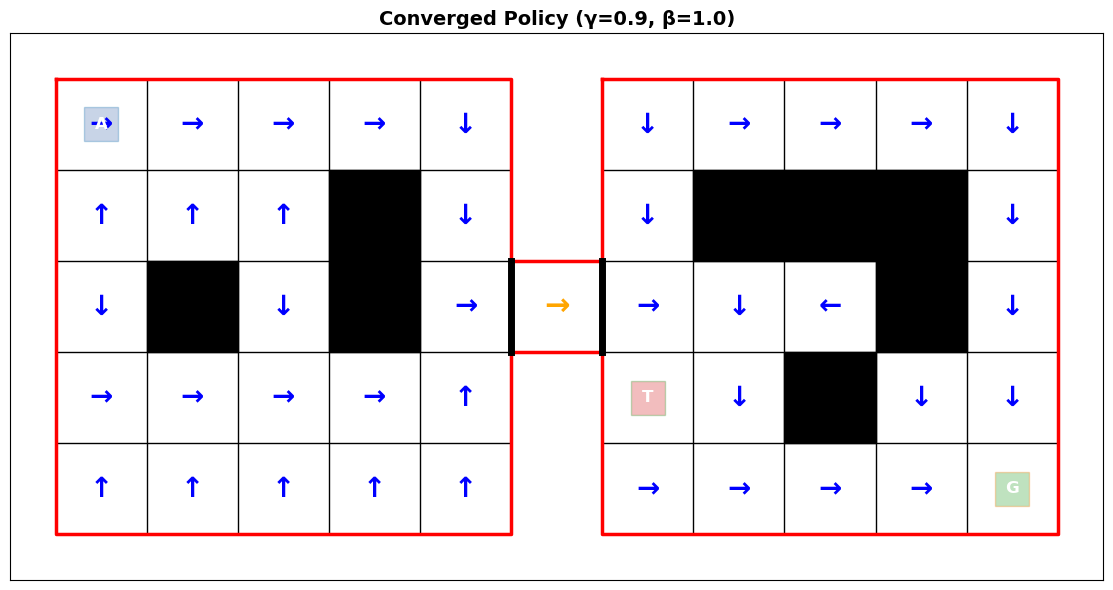

Saved figure: question2_fig/value_function_gamma_0.9_beta_1.0.png


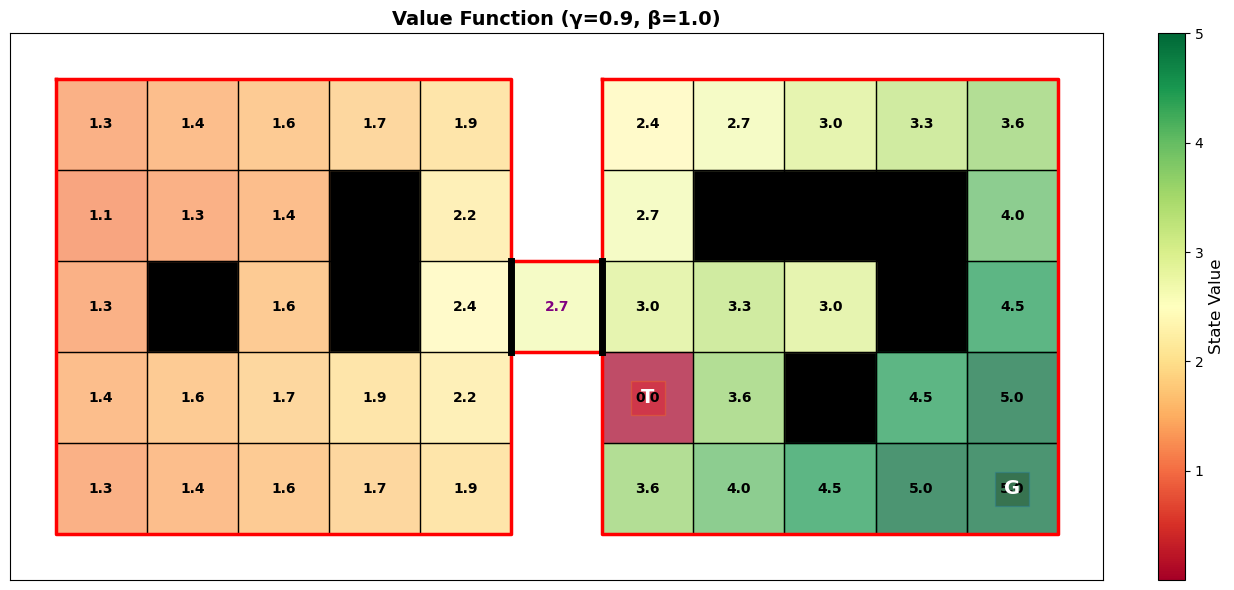

Saved figure: question2_fig/reward_curve_gamma_0.9_beta_1.0.png


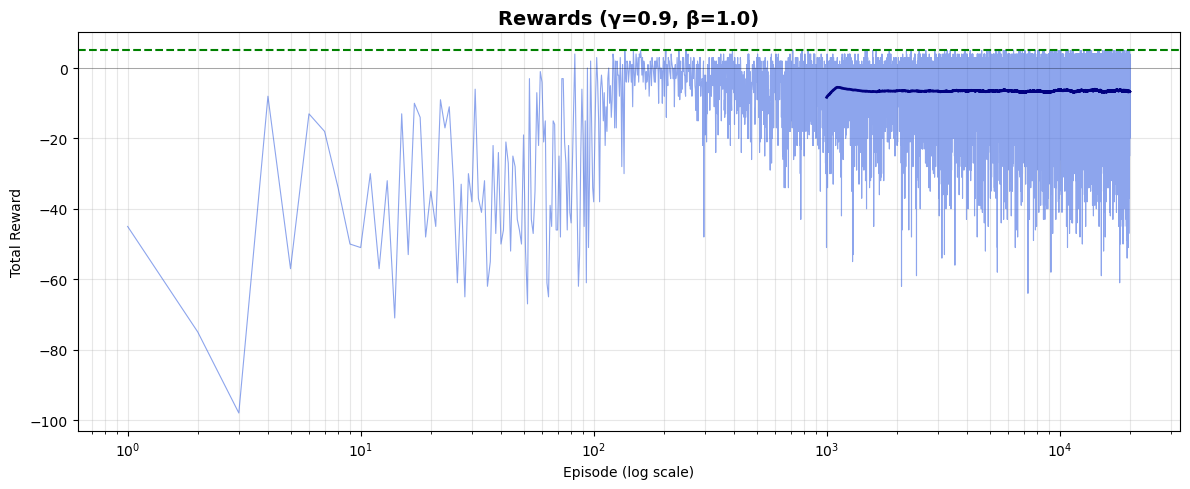

Saved figure: question2_fig/steps_curve_gamma_0.9_beta_1.0.png


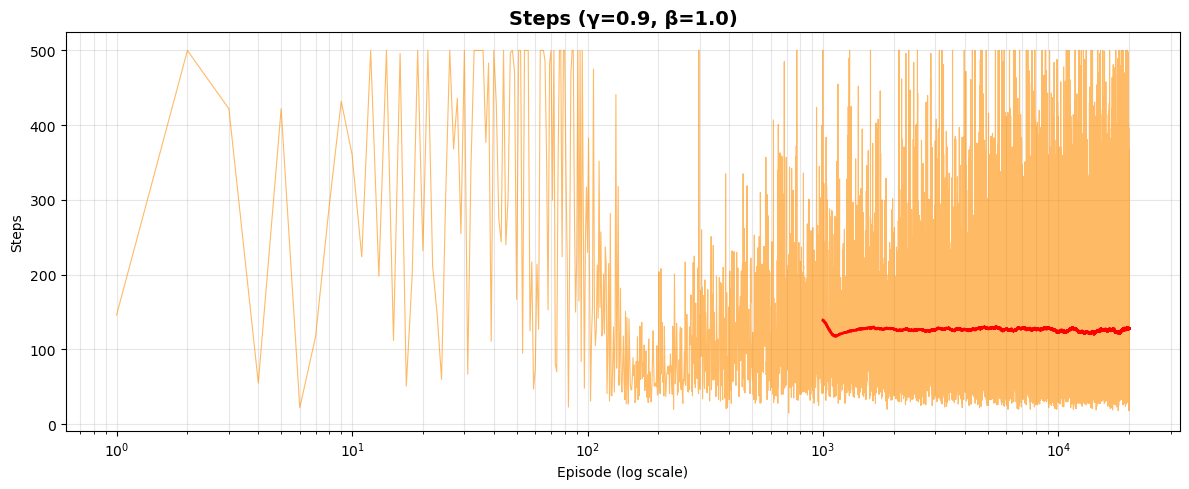

Visualization complete for γ=0.9, β=1.0.


In [20]:
print(f"Gamma: {DISCOUNT_FACTOR}, BETA: {BETA}, Learning Rate: {LEARNING_RATE}")
Q_table, ep_rewards, ep_steps = run_q_learning(DISCOUNT_FACTOR, BETA)
plot_policy_and_value_function(Q_table, ep_rewards, ep_steps, DISCOUNT_FACTOR, BETA)

## Section 2: Constant Beta and Variable Gamma

For ε = 0.1 and different values of γ = 0.1, 0.5, 0.9


Training for: Gamma=0.1, BETA=0.1
    Episode 2000/20000 - Avg steps (last 2000): 307.55, Avg reward: -65.81
    Episode 4000/20000 - Avg steps (last 2000): 303.22, Avg reward: -65.16
    Episode 6000/20000 - Avg steps (last 2000): 311.33, Avg reward: -66.91
    Episode 8000/20000 - Avg steps (last 2000): 300.84, Avg reward: -64.52
    Episode 10000/20000 - Avg steps (last 2000): 307.23, Avg reward: -66.16
    Episode 12000/20000 - Avg steps (last 2000): 306.84, Avg reward: -65.59
    Episode 14000/20000 - Avg steps (last 2000): 312.21, Avg reward: -67.00
    Episode 16000/20000 - Avg steps (last 2000): 310.27, Avg reward: -66.70
    Episode 18000/20000 - Avg steps (last 2000): 306.03, Avg reward: -66.28
    Episode 20000/20000 - Avg steps (last 2000): 303.22, Avg reward: -64.84
Saved figure: question2_fig/policy_gamma_0.1_beta_0.1.png


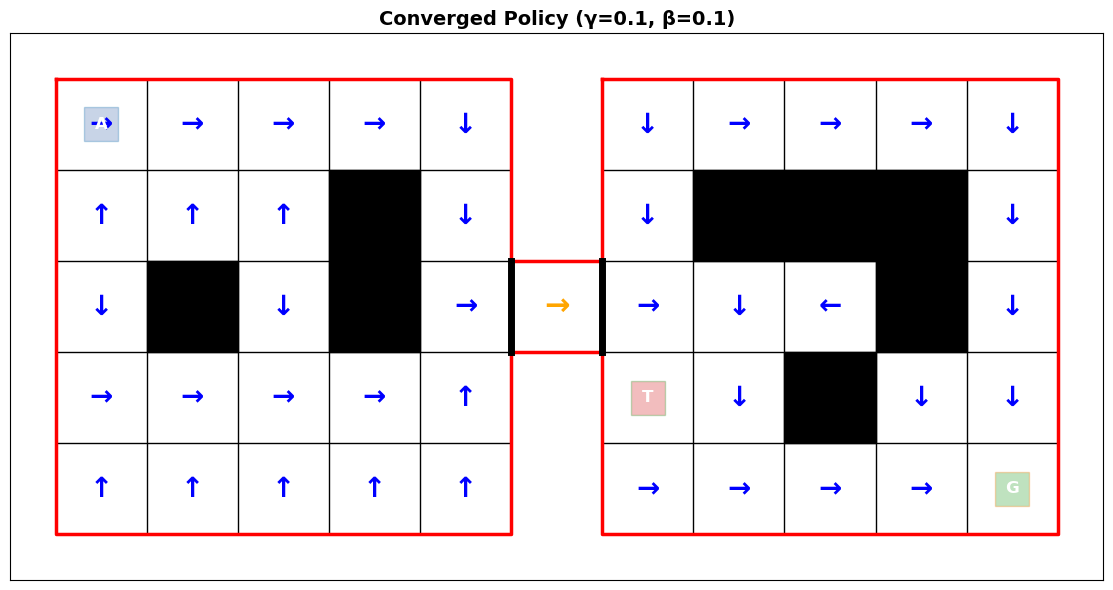

Saved figure: question2_fig/value_function_gamma_0.1_beta_0.1.png


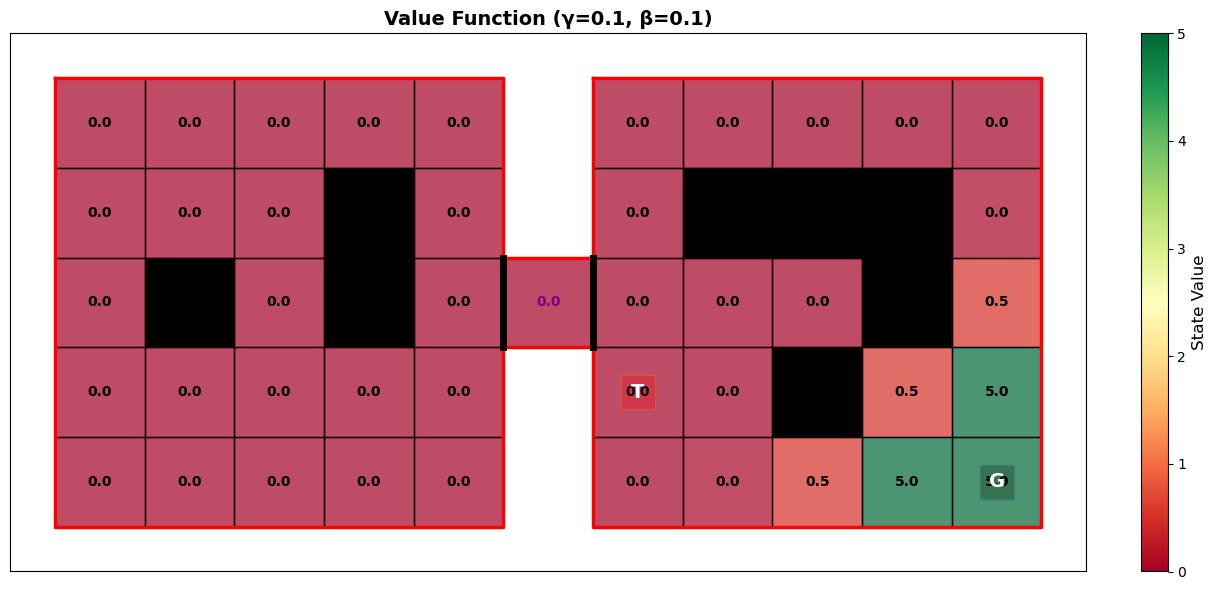

Saved figure: question2_fig/reward_curve_gamma_0.1_beta_0.1.png


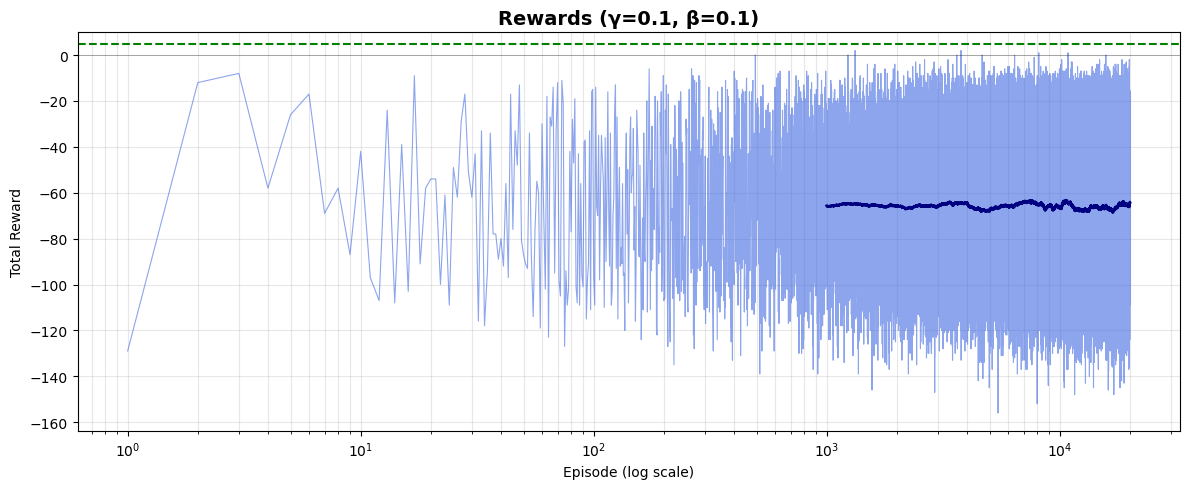

Saved figure: question2_fig/steps_curve_gamma_0.1_beta_0.1.png


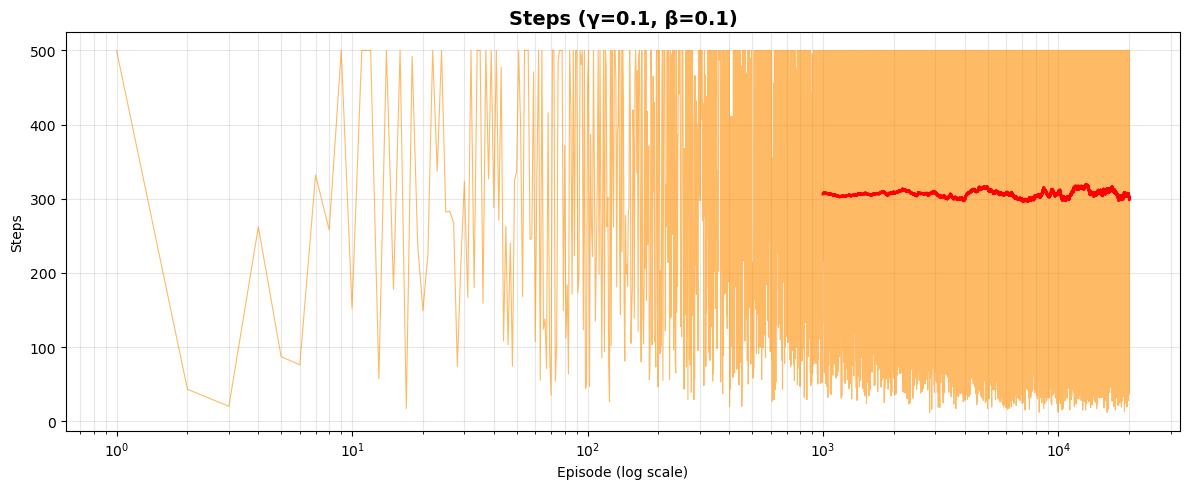

Visualization complete for γ=0.1, β=0.1.

Training for: Gamma=0.5, BETA=0.1
    Episode 2000/20000 - Avg steps (last 2000): 306.97, Avg reward: -64.77
    Episode 4000/20000 - Avg steps (last 2000): 304.93, Avg reward: -65.58
    Episode 6000/20000 - Avg steps (last 2000): 299.71, Avg reward: -63.90
    Episode 8000/20000 - Avg steps (last 2000): 302.75, Avg reward: -64.69
    Episode 10000/20000 - Avg steps (last 2000): 306.39, Avg reward: -65.14
    Episode 12000/20000 - Avg steps (last 2000): 295.79, Avg reward: -63.23
    Episode 14000/20000 - Avg steps (last 2000): 303.40, Avg reward: -64.74
    Episode 16000/20000 - Avg steps (last 2000): 301.99, Avg reward: -64.56
    Episode 18000/20000 - Avg steps (last 2000): 307.16, Avg reward: -65.82
    Episode 20000/20000 - Avg steps (last 2000): 305.03, Avg reward: -65.17
Saved figure: question2_fig/policy_gamma_0.5_beta_0.1.png


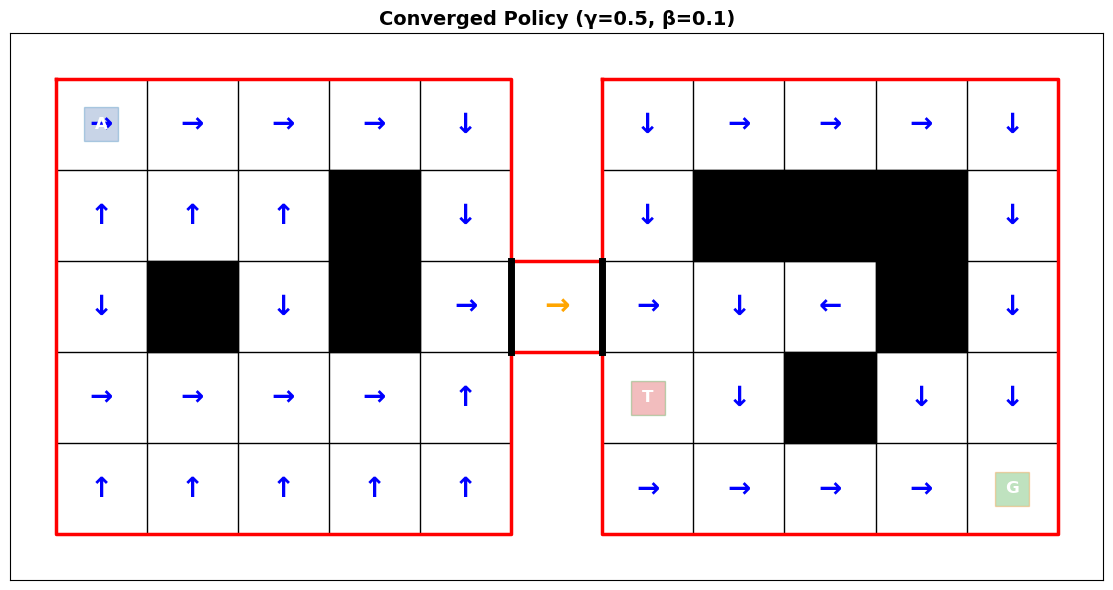

Saved figure: question2_fig/value_function_gamma_0.5_beta_0.1.png


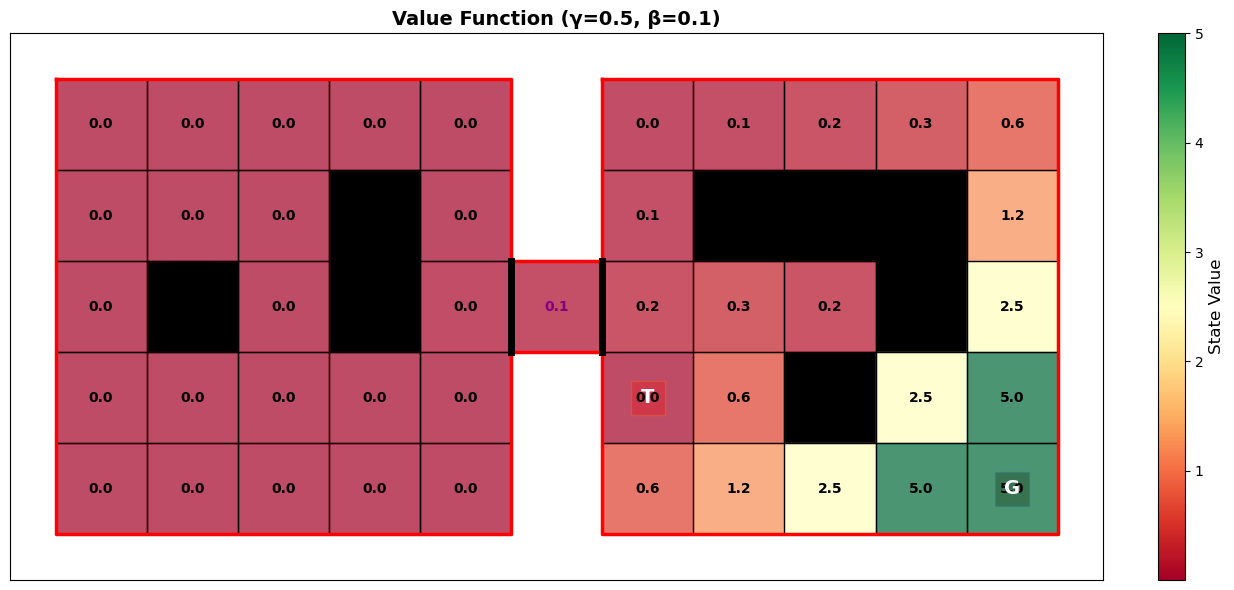

Saved figure: question2_fig/reward_curve_gamma_0.5_beta_0.1.png


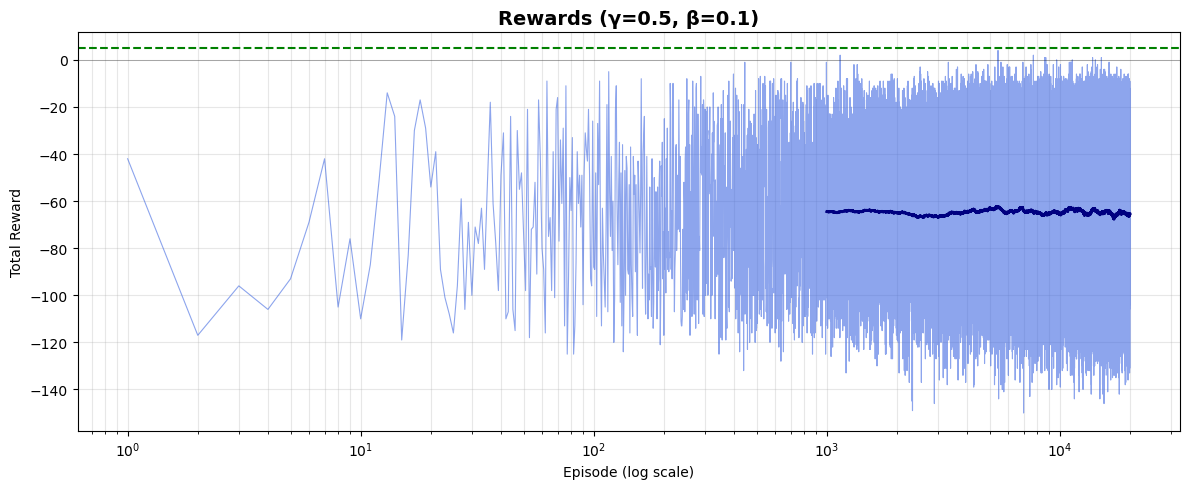

Saved figure: question2_fig/steps_curve_gamma_0.5_beta_0.1.png


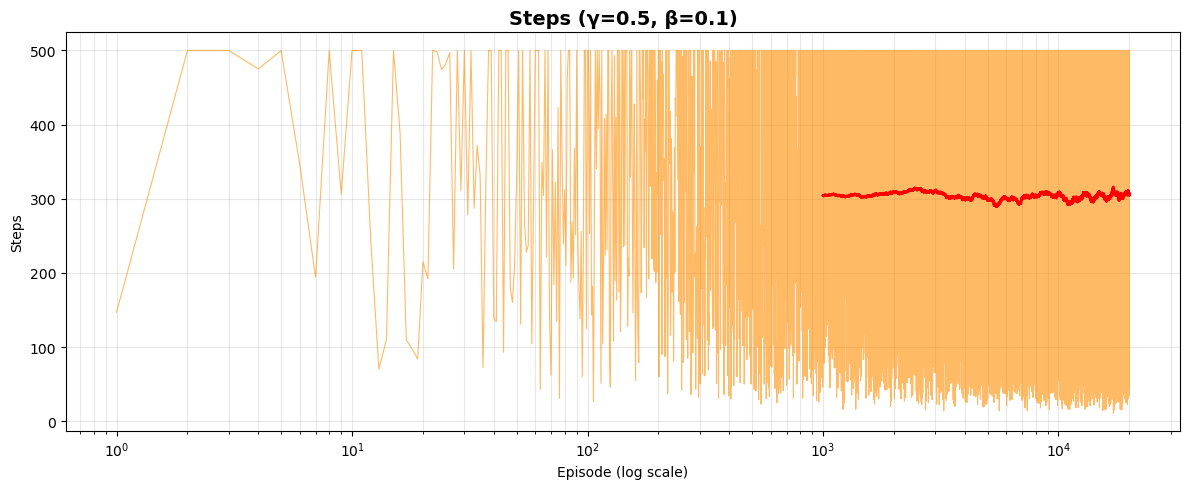

Visualization complete for γ=0.5, β=0.1.

Training for: Gamma=0.9, BETA=0.1
    Episode 2000/20000 - Avg steps (last 2000): 289.44, Avg reward: -61.70
    Episode 4000/20000 - Avg steps (last 2000): 286.51, Avg reward: -61.67
    Episode 6000/20000 - Avg steps (last 2000): 295.88, Avg reward: -63.04
    Episode 8000/20000 - Avg steps (last 2000): 287.91, Avg reward: -61.23
    Episode 10000/20000 - Avg steps (last 2000): 286.88, Avg reward: -61.37
    Episode 12000/20000 - Avg steps (last 2000): 284.69, Avg reward: -60.77
    Episode 14000/20000 - Avg steps (last 2000): 289.64, Avg reward: -61.56
    Episode 16000/20000 - Avg steps (last 2000): 293.81, Avg reward: -62.59
    Episode 18000/20000 - Avg steps (last 2000): 289.94, Avg reward: -62.10
    Episode 20000/20000 - Avg steps (last 2000): 291.45, Avg reward: -62.31
Saved figure: question2_fig/policy_gamma_0.9_beta_0.1.png


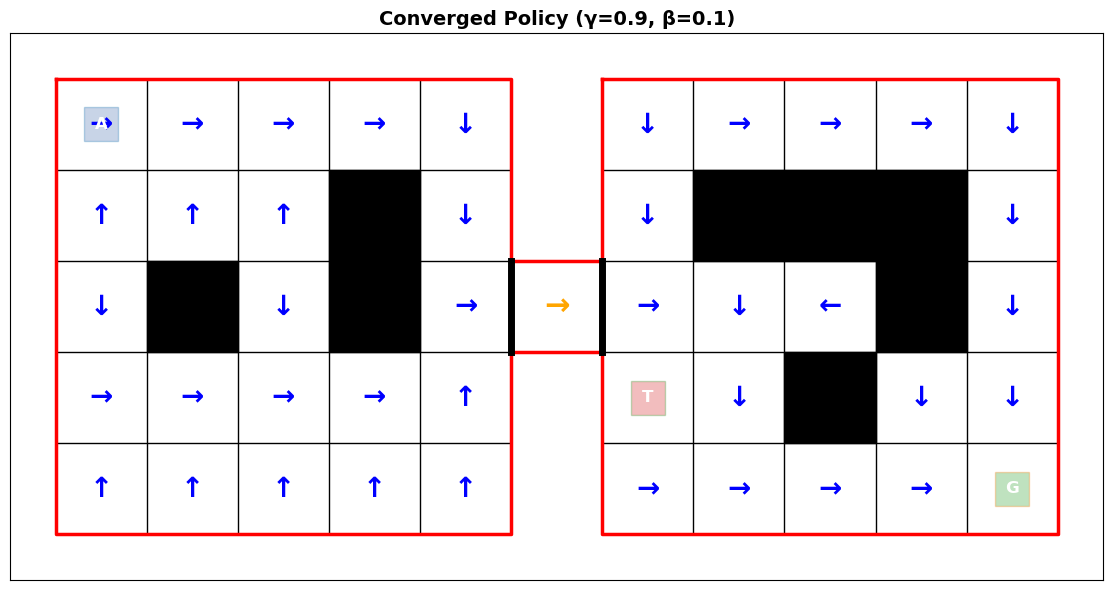

Saved figure: question2_fig/value_function_gamma_0.9_beta_0.1.png


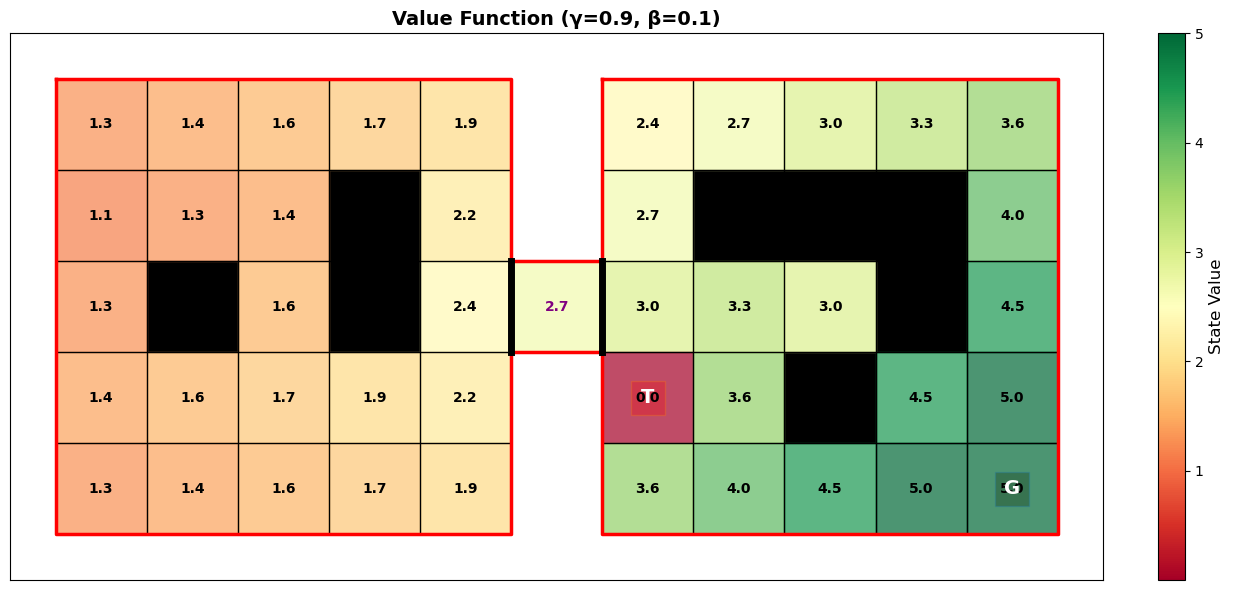

Saved figure: question2_fig/reward_curve_gamma_0.9_beta_0.1.png


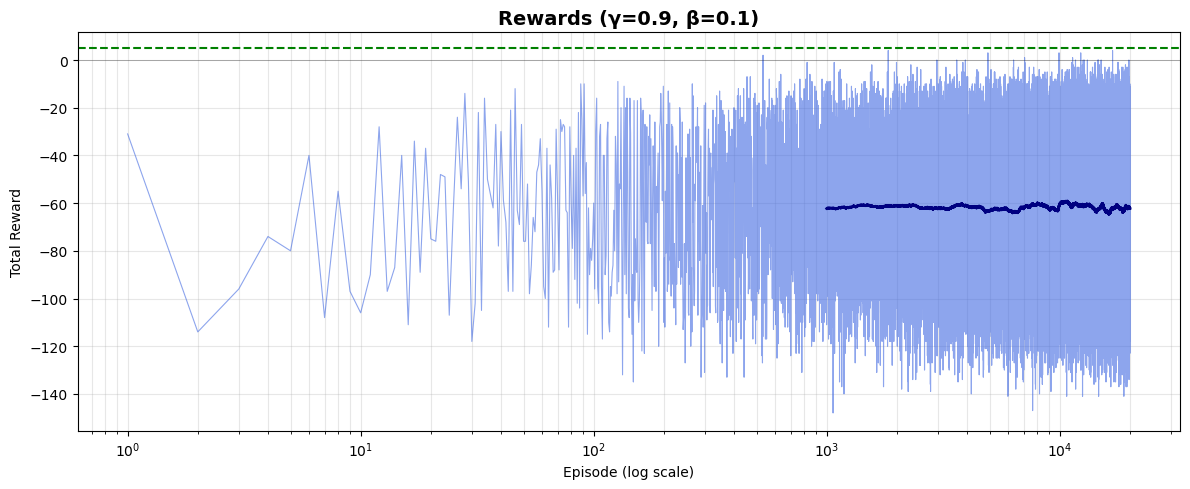

Saved figure: question2_fig/steps_curve_gamma_0.9_beta_0.1.png


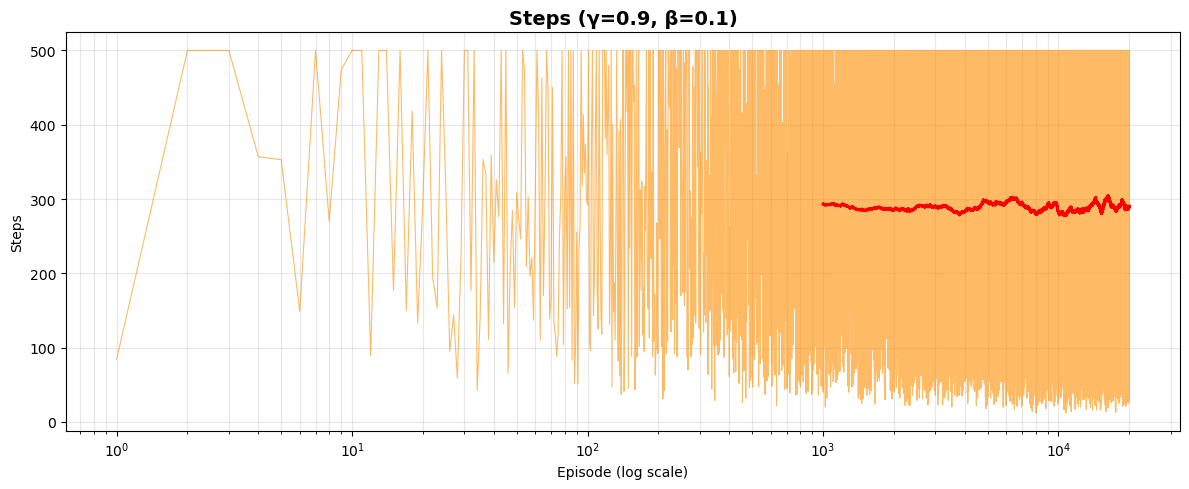

Visualization complete for γ=0.9, β=0.1.


In [21]:
gammas = [0.1, 0.5, 0.9]
beta_const = 0.1

for gamma in gammas:
    print(f"\nTraining for: Gamma={gamma}, BETA={beta_const}")
    Q_table, ep_rewards, ep_steps = run_q_learning(gamma, beta_const)
    plot_policy_and_value_function(Q_table, ep_rewards, ep_steps, gamma, beta_const)

## Section 3: Constant Gamma and Variable BETA

For γ = 0.9 and different values of β = 0.1, 0.3, 0.5

In [24]:
def print_beta_statistics(beta, final_steps, steps_runs):
    """Print statistics for a specific beta value"""
    all_steps_data[beta] = steps_runs
    print(f"\n📊 Episode Statistics for β={beta} (first stored run):")
    print(f"  • Total Episodes: {len(final_steps)}")
    print(f"  • Mean Steps: {np.mean(final_steps):.2f}")
    print(f"  • Std Dev Steps: {np.std(final_steps):.2f}")
    print(f"  • Min Steps: {np.min(final_steps)} (Episode {np.argmin(final_steps) + 1})")
    print(f"  • Max Steps: {np.max(final_steps)} (Episode {np.argmax(final_steps) + 1})")
    print(f"  • First 5 Episodes Steps: {final_steps[:5]}")
    print(f"  • Last 5 Episodes Steps: {final_steps[-5:]}")

def train_beta(beta, gamma_const, num_runs):
    """Train Q-learning for a specific beta value"""
    print(f"\nTraining for: Gamma={gamma_const}, BETA={beta}")
    steps_runs = []
    final_q_table = None
    final_rewards = None
    final_steps = None
    
    for run in range(num_runs):
        print(f"  Run {run + 1}/{num_runs}:")
        q_table, rewards_list, steps_list = run_q_learning(gamma_const, beta)
        steps_runs.append(steps_list)
        if run == 0:
            final_q_table = q_table
            final_rewards = rewards_list
            final_steps = steps_list
    
    steps_runs = np.array(steps_runs)
    plot_policy_and_value_function(final_q_table, final_rewards, final_steps, gamma_const, beta)
    return steps_runs, final_steps

# Setup
gamma_const = 0.9
num_runs = 5 
all_steps_data = {}


Training for: Gamma=0.9, BETA=0.1
  Run 1/5:
    Episode 2000/20000 - Avg steps (last 2000): 296.51, Avg reward: -63.24
    Episode 4000/20000 - Avg steps (last 2000): 294.44, Avg reward: -62.97
    Episode 6000/20000 - Avg steps (last 2000): 290.75, Avg reward: -62.22
    Episode 8000/20000 - Avg steps (last 2000): 286.50, Avg reward: -61.28
    Episode 10000/20000 - Avg steps (last 2000): 293.11, Avg reward: -62.26
    Episode 12000/20000 - Avg steps (last 2000): 295.63, Avg reward: -63.17
    Episode 14000/20000 - Avg steps (last 2000): 296.63, Avg reward: -63.36
    Episode 16000/20000 - Avg steps (last 2000): 282.61, Avg reward: -60.28
    Episode 18000/20000 - Avg steps (last 2000): 294.25, Avg reward: -62.60
    Episode 20000/20000 - Avg steps (last 2000): 281.82, Avg reward: -60.12
  Run 2/5:
    Episode 2000/20000 - Avg steps (last 2000): 295.02, Avg reward: -63.21
    Episode 4000/20000 - Avg steps (last 2000): 293.95, Avg reward: -62.33
    Episode 6000/20000 - Avg steps (l

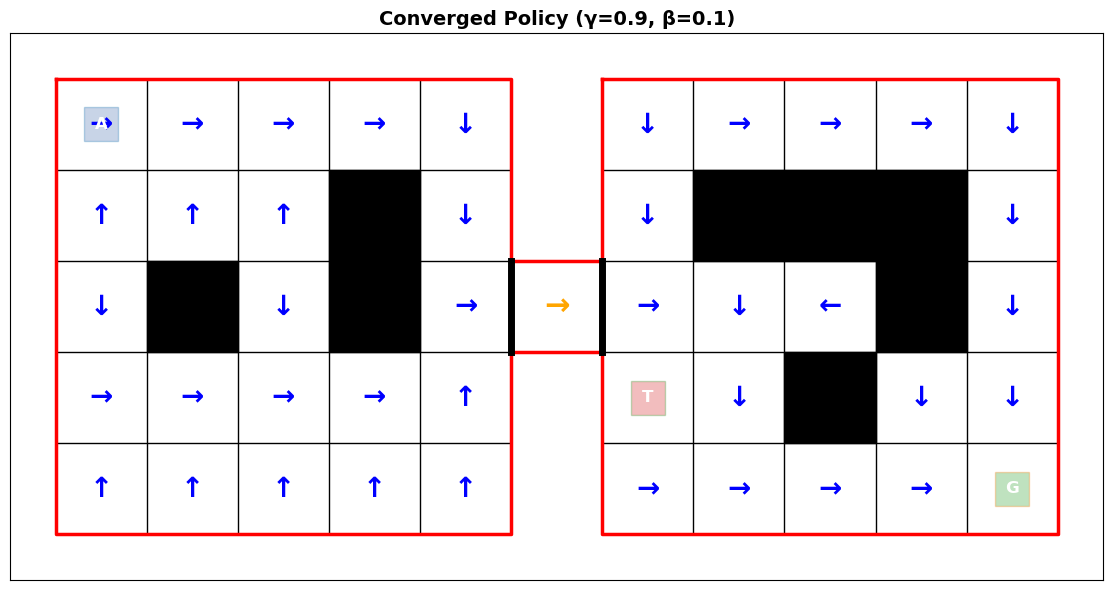

Saved figure: question2_fig/value_function_gamma_0.9_beta_0.1.png


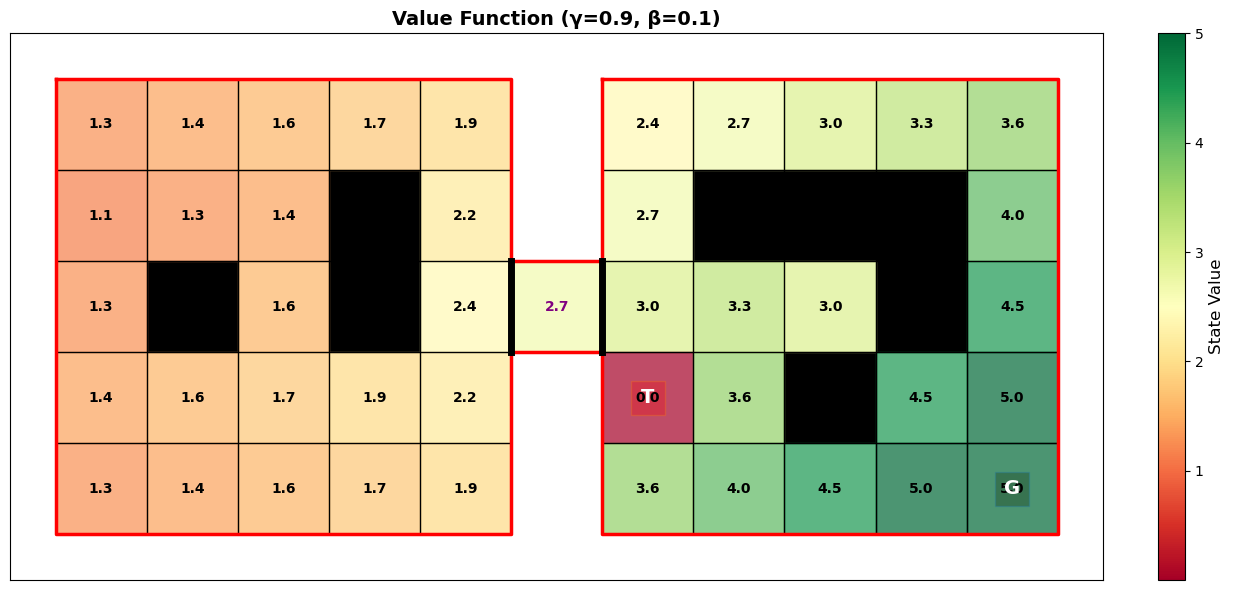

Saved figure: question2_fig/reward_curve_gamma_0.9_beta_0.1.png


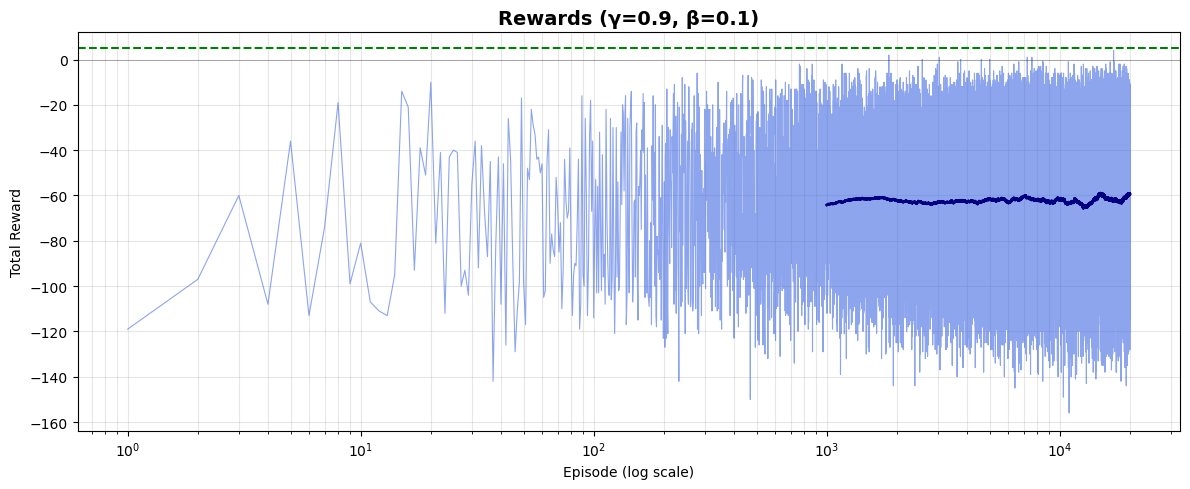

Saved figure: question2_fig/steps_curve_gamma_0.9_beta_0.1.png


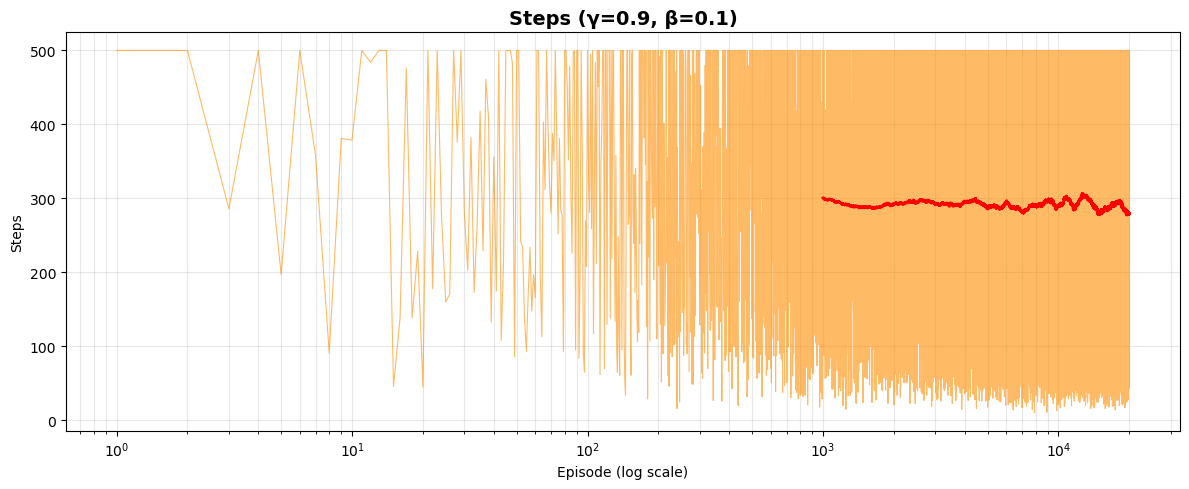

Visualization complete for γ=0.9, β=0.1.

📊 Episode Statistics for β=0.1 (first stored run):
  • Total Episodes: 20000
  • Mean Steps: 291.22
  • Std Dev Steps: 160.85
  • Min Steps: 10 (Episode 7909)
  • Max Steps: 500 (Episode 1)
  • First 5 Episodes Steps: [500, 500, 286, 500, 197]
  • Last 5 Episodes Steps: [84, 137, 197, 261, 44]


In [25]:
# Train Beta 0.1
beta = 0.1
steps_runs, final_steps = train_beta(beta, gamma_const, num_runs)
print_beta_statistics(beta, final_steps, steps_runs)


Training for: Gamma=0.9, BETA=0.3
  Run 1/20:
  Run 2/20:
  Run 2/20:
  Run 3/20:
  Run 3/20:
  Run 4/20:  Run 4/20:
  Run 5/20:

  Run 5/20:
  Run 6/20:
  Run 6/20:
  Run 7/20:
  Run 7/20:
  Run 8/20:
  Run 8/20:
  Run 9/20:
  Run 9/20:
  Run 10/20:
  Run 11/20:
  Run 10/20:
  Run 11/20:
  Run 12/20:
  Run 12/20:
  Run 13/20:
  Run 14/20:
  Run 13/20:
  Run 14/20:
  Run 15/20:
  Run 15/20:
  Run 16/20:
  Run 17/20:
  Run 16/20:
  Run 17/20:
  Run 18/20:
  Run 18/20:
  Run 19/20:
  Run 20/20:
  Run 19/20:
  Run 20/20:
Saved figure: question2_fig/policy_gamma_0.9_beta_0.3.png
Saved figure: question2_fig/policy_gamma_0.9_beta_0.3.png


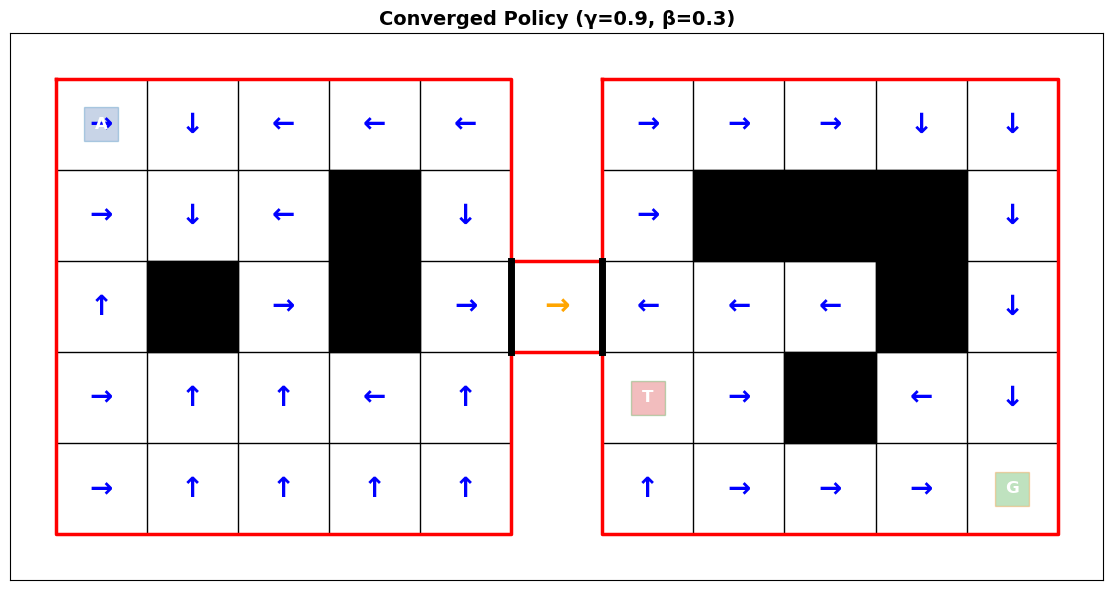

Saved figure: question2_fig/value_function_gamma_0.9_beta_0.3.png


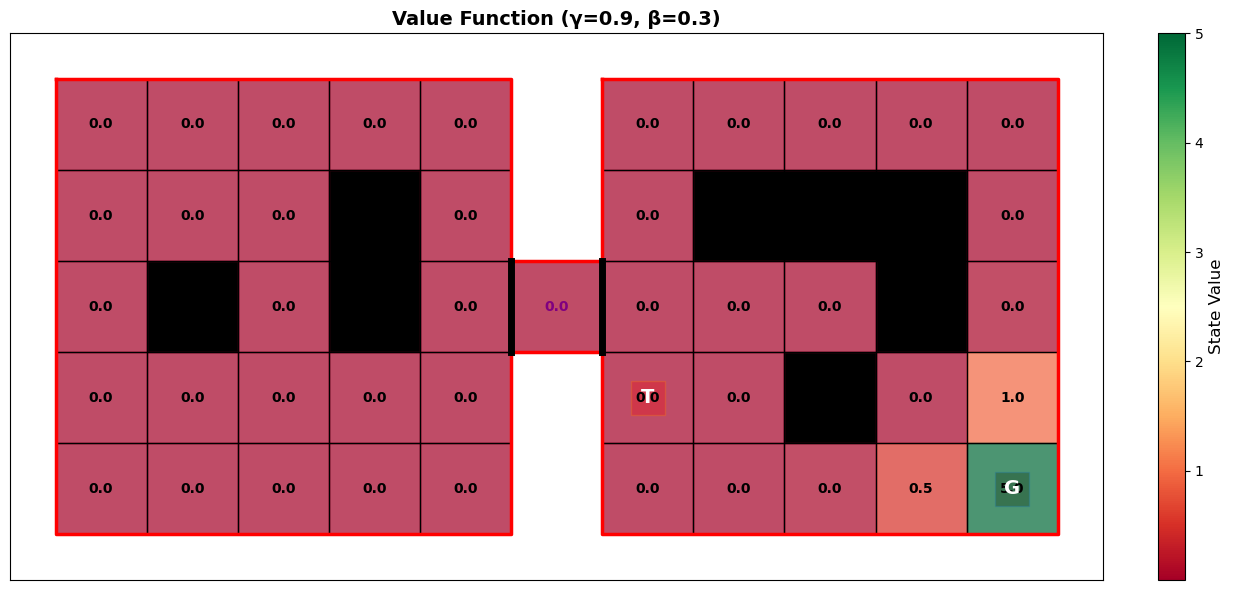

Saved figure: question2_fig/reward_curve_gamma_0.9_beta_0.3.png


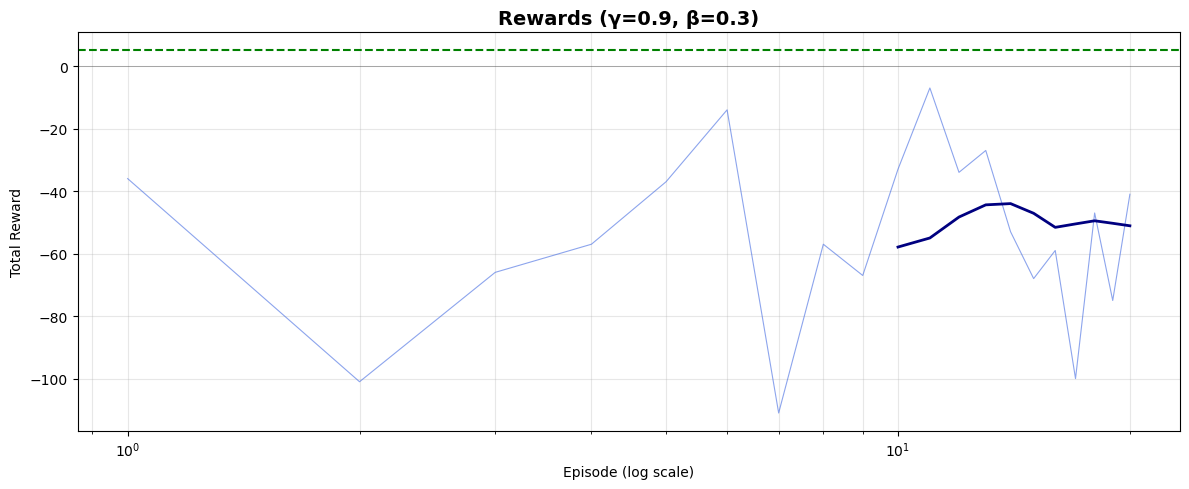

Saved figure: question2_fig/steps_curve_gamma_0.9_beta_0.3.png


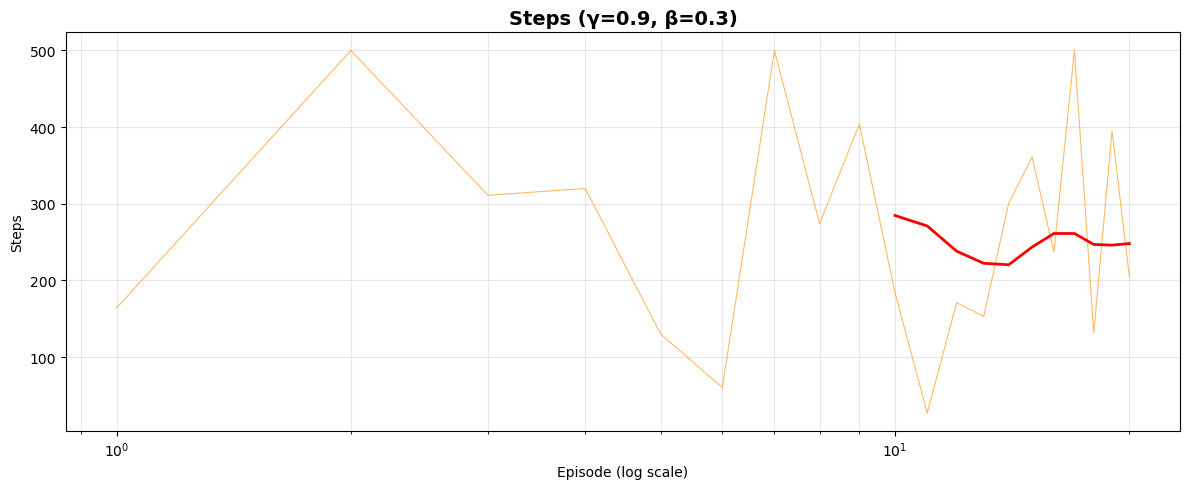

Visualization complete for γ=0.9, β=0.3.

📊 Episode Statistics for β=0.3 (first stored run):
  • Total Episodes: 20
  • Mean Steps: 266.40
  • Std Dev Steps: 140.53
  • Min Steps: 27 (Episode 11)
  • Max Steps: 500 (Episode 2)
  • First 5 Episodes Steps: [164, 500, 311, 320, 130]
  • Last 5 Episodes Steps: [237, 500, 131, 395, 205]


In [ ]:
# Train Beta 0.3
beta = 0.3
steps_runs, final_steps = train_beta(beta, gamma_const, num_runs)
print_beta_statistics(beta, final_steps, steps_runs)


Training for: Gamma=0.9, BETA=0.5
  Run 1/20:
  Run 2/20:
  Run 2/20:
  Run 3/20:
  Run 3/20:
  Run 4/20:
  Run 4/20:
  Run 5/20:
  Run 5/20:
  Run 6/20:  Run 6/20:
  Run 7/20:
  Run 8/20:
  Run 7/20:
  Run 8/20:

  Run 9/20:
  Run 9/20:
  Run 10/20:
  Run 11/20:
  Run 10/20:
  Run 11/20:
  Run 12/20:
  Run 13/20:
  Run 12/20:
  Run 13/20:
  Run 14/20:
  Run 14/20:
  Run 15/20:
  Run 16/20:
  Run 15/20:
  Run 16/20:
  Run 17/20:
  Run 17/20:
  Run 18/20:
  Run 19/20:
  Run 18/20:
  Run 19/20:
  Run 20/20:
  Run 20/20:
Saved figure: question2_fig/policy_gamma_0.9_beta_0.5.png
Saved figure: question2_fig/policy_gamma_0.9_beta_0.5.png


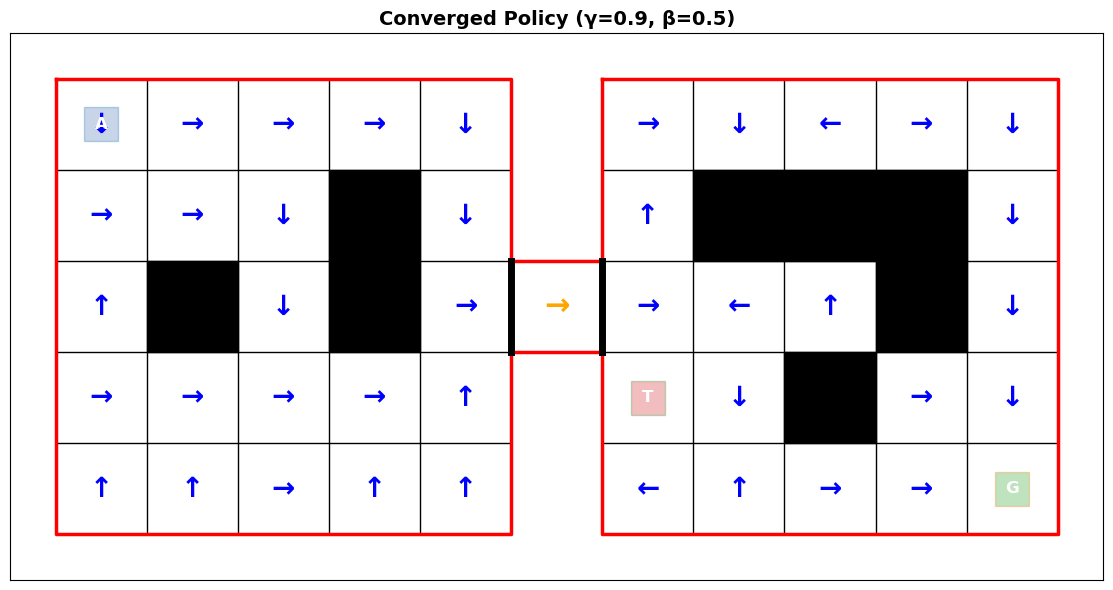

Saved figure: question2_fig/value_function_gamma_0.9_beta_0.5.png


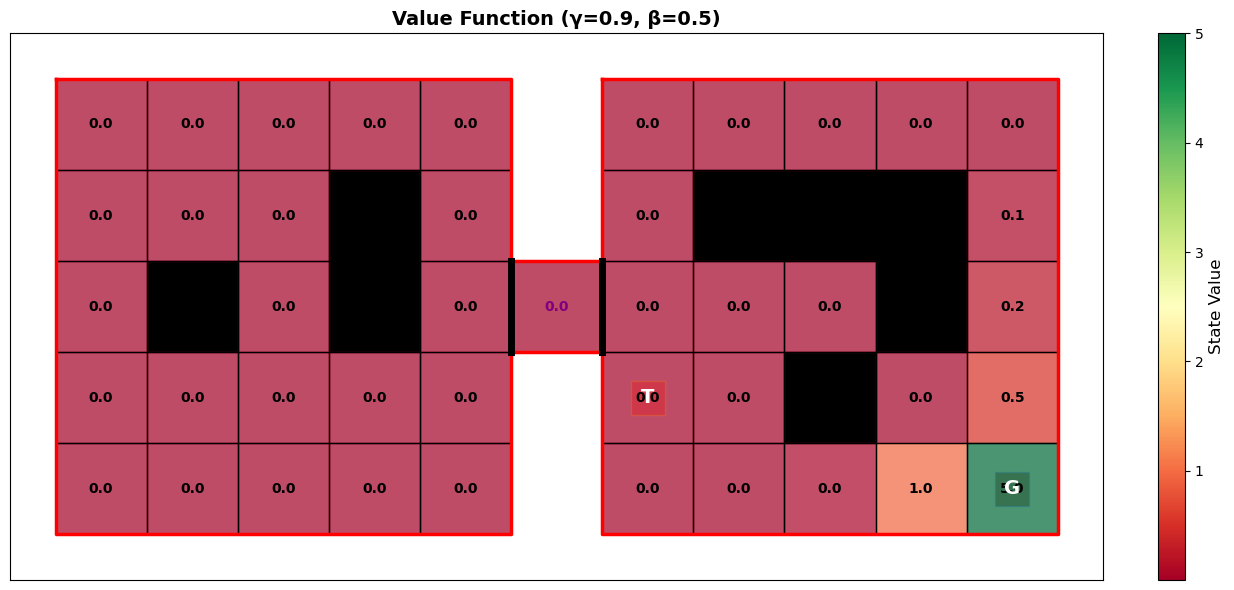

Saved figure: question2_fig/reward_curve_gamma_0.9_beta_0.5.png


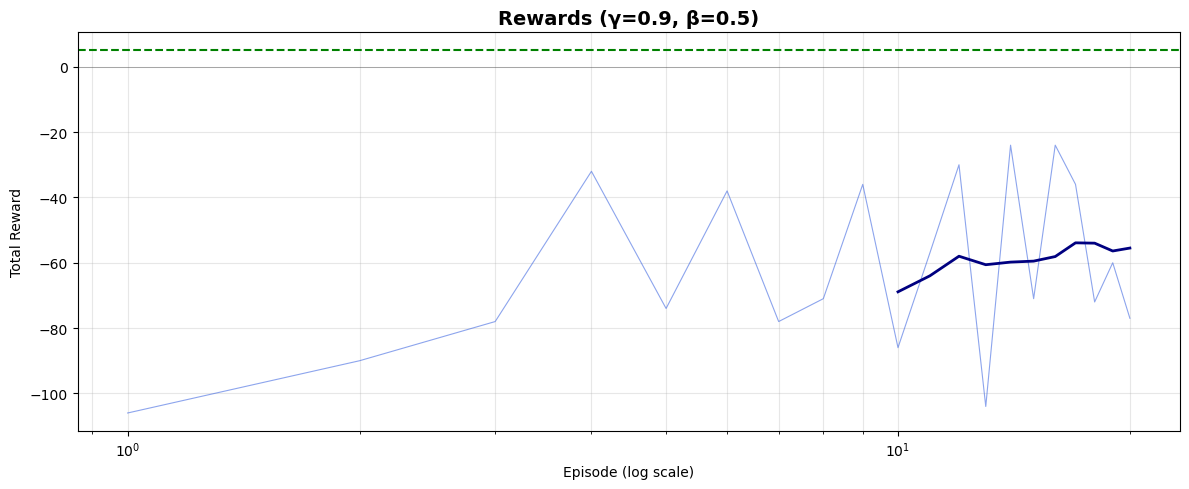

Saved figure: question2_fig/steps_curve_gamma_0.9_beta_0.5.png


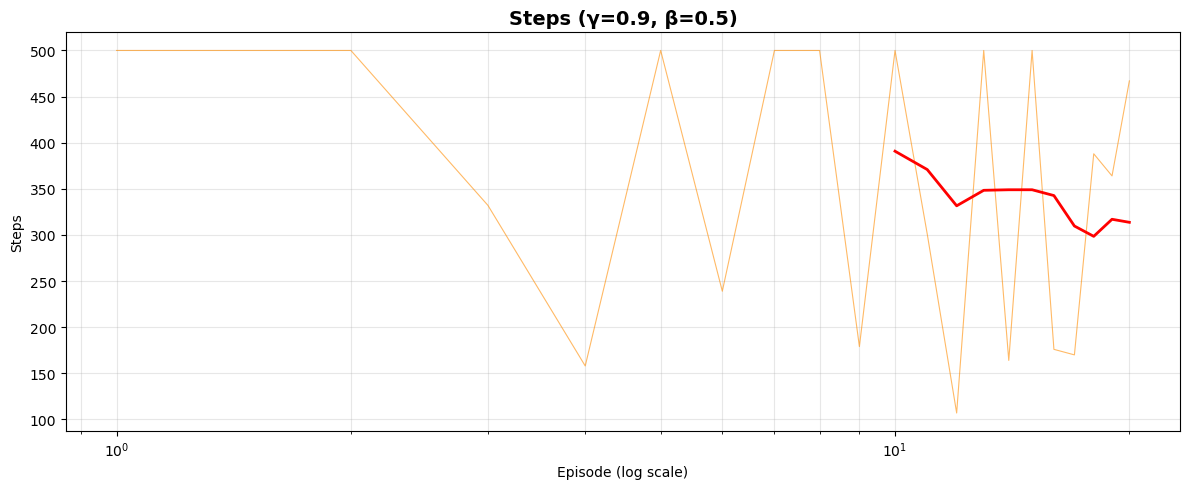

Visualization complete for γ=0.9, β=0.5.

📊 Episode Statistics for β=0.5 (first stored run):
  • Total Episodes: 20
  • Mean Steps: 352.25
  • Std Dev Steps: 147.09
  • Min Steps: 107 (Episode 12)
  • Max Steps: 500 (Episode 1)
  • First 5 Episodes Steps: [500, 500, 332, 158, 500]
  • Last 5 Episodes Steps: [176, 170, 388, 364, 467]


In [ ]:
# Train Beta 0.5
beta = 0.5
steps_runs, final_steps = train_beta(beta, gamma_const, num_runs)
print_beta_statistics(beta, final_steps, steps_runs)

In [26]:
def plot_learning_curve(all_steps_data, gamma):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    for beta, steps_runs in all_steps_data.items():
        steps_runs = np.array(steps_runs)
        avg_steps = np.mean(steps_runs, axis=0)
        std_steps = np.std(steps_runs, axis=0)
        episodes = np.arange(1, len(avg_steps) + 1)
        log_episodes = np.log(episodes)

        ax.plot(log_episodes, avg_steps, label=f'β={beta}')
        ax.fill_between(log_episodes, avg_steps - std_steps, avg_steps + std_steps, alpha=0.2)

    ax.set_xlabel('log(Episode)')
    ax.set_ylabel('Steps to Goal')
    ax.set_title(f'Learning Curve (γ={gamma})', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    save_or_show(fig, "learning_curve", gamma)


Saved figure: question2_fig/learning_curve_gamma_0.9_beta_1.0.png


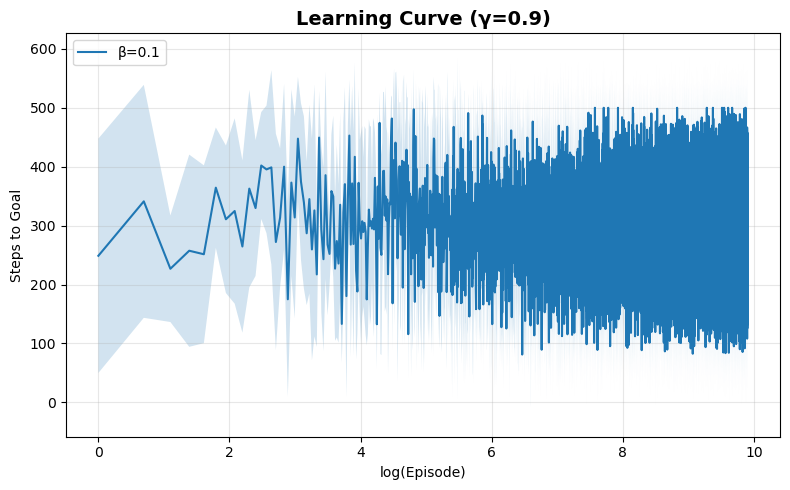

In [27]:
plot_learning_curve(all_steps_data, gamma_const)